# AIHW Suicide Mortality Data -- Analysis and Visualisation

**Input:** Five cleaned DataFrames from notebook 02  
**Output:** Five charts with written analytical interpretation

This notebook re-runs the cleaning steps from notebook 02 (so it is self-contained),
then produces one chart per table. Each chart is followed by a written interpretation
section that contextualises the finding within Australian public health.

Charts produced:
1. National trend by sex, 1968-2024 (NMD1)
2. Remoteness gradient, 2001-2024 (NMD5)
3. Youth rates by age band, 2001-2024 (NMD13)
4. Deaths of despair by cause and sex, 1997-2024 (NMD16)
5. Top psychosocial risk factors by sex and age group, 2024 (NMD17)

## 1. Setup and data loading

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Use a clean, minimal style for all charts
plt.style.use('seaborn-v0_8-whitegrid')

FILE_PATH = 'Data/AIHW_suicide-and-self-harm-monitoring_NMD_suicide_2024.xlsx'
SUPPRESSION_CODES = ['. .', 'n.p.', 'n.a.']

# Consistent colour palette used across all charts
# Using accessible colours that distinguish Male/Female/combined clearly
COLOURS = {
    'Males':    '#2166ac',   # blue
    'Females':  '#d6604d',   # red-orange
    'Persons':  '#4d9221',   # green
}

# Remoteness area colours - ordered light to dark by increasing remoteness
REMOTE_COLOURS = [
    '#ffffb2', '#fecc5c', '#fd8d3c', '#f03b20', '#bd0026'
]

print('Setup complete.')

Setup complete.


## 2. Rebuild cleaned DataFrames

This section re-runs the cleaning from notebook 02 with two patches applied:
- NMD13: footer rows filtered out before melting
- NMD17: Unicode en-dash normalised to plain hyphen in Age_group column

These were identified during the exploration phase when inspecting raw values.

In [15]:
def replace_suppression(df, col):
    # Replace all AIHW suppression codes with NaN in a given column
    for code in SUPPRESSION_CODES:
        df[col] = df[col].replace(code, np.nan)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

# --- NMD1: national trend by sex ---
df1 = pd.read_excel(FILE_PATH, sheet_name='Table NMD 1', header=1)
df1 = df1[
    (df1['Measure'] == 'Age-standardised rate (per 100,000)') &
    (df1['Sex'].isin(['Males', 'Females', 'Persons']))
].copy()
year_cols1 = [c for c in df1.columns if isinstance(c, int)]
df1_long = pd.melt(df1, id_vars=['Sex'], value_vars=year_cols1, var_name='Year', value_name='Rate')
df1_long = replace_suppression(df1_long, 'Rate')
df1_long['Year'] = df1_long['Year'].astype(int)

# --- NMD5: remoteness area ---
df5 = pd.read_excel(FILE_PATH, sheet_name='Table NMD 5', header=1)
df5['Sex'] = df5['Sex'].str.strip()
df5['Remoteness area'] = df5['Remoteness area'].str.strip()
df5 = df5[
    (df5['Measure'] == 'Age-standardised rate (per 100,000)') &
    (df5['Remoteness area'] != 'Total Australia')
].copy()
year_cols5 = [c for c in df5.columns if isinstance(c, int)]
df5_long = pd.melt(df5, id_vars=['Remoteness area','Sex'], value_vars=year_cols5, var_name='Year', value_name='Rate')
df5_long = replace_suppression(df5_long, 'Rate')
df5_long['Year'] = df5_long['Year'].astype(int)

# Ordered list for consistent legend/chart ordering
REMOTE_ORDER = ['Major Cities', 'Inner Regional', 'Outer Regional', 'Remote', 'Very Remote']

# --- NMD13: youth rates ---
df13 = pd.read_excel(FILE_PATH, sheet_name='Table NMD 13a', header=1)
# PATCH: the raw sheet has footnote text leaked into the Age group column.
# We keep only rows where Age group matches a recognised age band.
# The en-dash character (U+2013) is used in AIHW age ranges, not a plain hyphen.
valid_age_groups = ['0\u201314','5\u201314','5\u201317','15\u201317','18\u201324','0\u201324','5\u201324']
df13 = df13[
    (df13['Measure'] == 'Age-specific rate (per 100,000)') &
    (df13['Age group'].isin(valid_age_groups))
].copy()
year_cols13 = [c for c in df13.columns if isinstance(c, int)]
df13_long = pd.melt(df13, id_vars=['Age group'], value_vars=year_cols13, var_name='Year', value_name='Rate')
df13_long = replace_suppression(df13_long, 'Rate')
df13_long['Year'] = df13_long['Year'].astype(int)
# Normalise en-dash to plain hyphen for readable labels in charts
df13_long['Age group'] = df13_long['Age group'].str.replace('\u2013', '-')

# --- NMD16: deaths of despair ---
df16 = pd.read_excel(FILE_PATH, sheet_name='Table NMD 16', header=1)
df16['Sex'] = df16['Sex'].str.strip()
df16 = df16[df16['Measure'] == 'Age-standardised rate (per 100,000)'].copy()
cause_labels = {
    'Alcoholic liver disease and cirrhosis': 'Alcohol-related',
    'Suicide': 'Suicide',
    'Accidental poisoning': 'Drug-related',
    'All combined (Alcoholic liver disease and cirrhosis, Suicide, Accidental poisoning)': 'All combined'
}
df16['Cause'] = df16['Selected causes of death'].map(cause_labels)
year_cols16 = [c for c in df16.columns if str(c).strip().isdigit()]
df16_long = pd.melt(df16, id_vars=['Cause','Sex'], value_vars=year_cols16, var_name='Year', value_name='Rate')
df16_long = replace_suppression(df16_long, 'Rate')
df16_long['Year'] = pd.to_numeric(df16_long['Year'], errors='coerce').astype(int)

# --- NMD17: psychosocial risk factors ---
df17 = pd.read_excel(FILE_PATH, sheet_name='Table NMD 17', header=1)
df17['Sex'] = df17['Sex'].str.strip()
df17 = df17.rename(columns={
    'Risk factor ':     'Risk_factor_raw',
    'Frequency rank':   'Rank',
    'Age group':        'Age_group',
    'Number':           'Deaths_with_factor',
    'Proportion':       'Pct_with_factor'
})
df17[['ICD10_code','Risk_factor_label']] = (
    df17['Risk_factor_raw'].str.strip().str.split(' ', n=1, expand=True)
)
df17 = df17.dropna(subset=['Year','Sex','Age_group'])
df17['Year'] = df17['Year'].astype(int)
# PATCH: normalise en-dash to plain hyphen in age groups
df17['Age_group'] = df17['Age_group'].str.replace('\u2013', '-').str.strip()
# Convert Rank and numeric columns -- object dtype causes nsmallest() to fail
df17['Rank'] = pd.to_numeric(df17['Rank'], errors='coerce')
df17['Pct_with_factor'] = pd.to_numeric(df17['Pct_with_factor'], errors='coerce')
df17['Deaths_with_factor'] = pd.to_numeric(df17['Deaths_with_factor'], errors='coerce')
df17 = df17[['ICD10_code','Risk_factor_label','Rank','Year','Sex','Age_group','Deaths_with_factor','Pct_with_factor']]

print('All five tables loaded and cleaned.')
print(f'NMD1:  {df1_long.shape}')
print(f'NMD5:  {df5_long.shape}')
print(f'NMD13: {df13_long.shape}')
print(f'NMD16: {df16_long.shape}')
print(f'NMD17: {df17.shape}')

/var/folders/69/qktlcbyn66z87k613hl1zt600000gn/T/ipykernel_14562/1805389113.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(code, np.nan)
/var/folders/69/qktlcbyn66z87k613hl1zt600000gn/T/ipykernel_14562/1805389113.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(code, np.nan)


All five tables loaded and cleaned.
NMD1:  (354, 3)
NMD5:  (360, 4)
NMD13: (168, 3)
NMD16: (336, 4)
NMD17: (1344, 8)


## 3. Chart 1 -- National trend by sex, 1968-2024

We start from 1968 rather than 1907 because age-standardised rates are only available
from 1968 onward. The earlier years in NMD1 contain crude rates which are not
comparable across time periods due to Australia's changing age structure.

Key things to look for before interpreting:
- The peak in male rates in the mid-1990s (around 1995-1997)
- The persistent male:female gap throughout the entire series
- The gradual decline from the late 1990s peak through to present

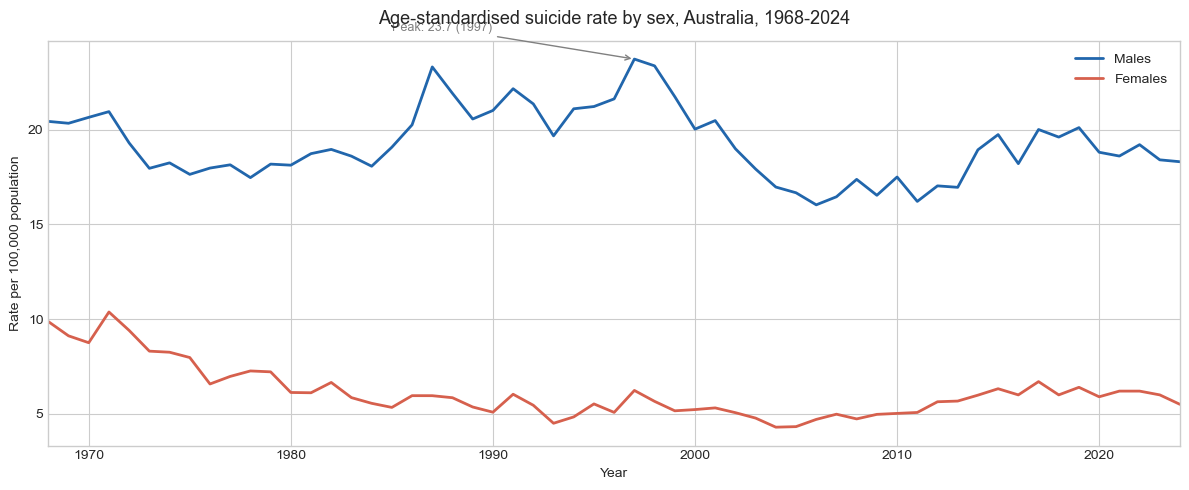

Chart saved.


In [10]:
# Filter to 1968 onwards and exclude 'Persons' for this chart
# (showing Males and Females separately is more informative here)
df1_plot = df1_long[
    (df1_long['Year'] >= 1968) &
    (df1_long['Sex'].isin(['Males', 'Females']))
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for sex in ['Males', 'Females']:
    subset = df1_plot[df1_plot['Sex'] == sex].sort_values('Year')
    ax.plot(
        subset['Year'],
        subset['Rate'],
        label=sex,
        color=COLOURS[sex],
        linewidth=2
    )

# Annotate the 1997 peak for males - this was the highest recorded rate
peak_row = df1_plot[(df1_plot['Sex']=='Males')].nlargest(1, 'Rate').iloc[0]
ax.annotate(
    f"Peak: {peak_row['Rate']:.1f} ({int(peak_row['Year'])})",
    xy=(peak_row['Year'], peak_row['Rate']),
    xytext=(peak_row['Year'] - 12, peak_row['Rate'] + 1.5),
    arrowprops=dict(arrowstyle='->', color='grey'),
    fontsize=9, color='grey'
)

ax.set_title('Age-standardised suicide rate by sex, Australia, 1968-2024', fontsize=13, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Rate per 100,000 population')
ax.legend()
ax.set_xlim(1968, 2024)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('charts/chart1_national_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### Interpretation -- Chart 1

From this chart, it can be seen that the female suicide rate in Australia peaked in 1971 with the age-standardised suicide rate at 10.4 per 100 000 women. This has been attributed to the widespread access of medications via the Pharmaceutical Benefits Scheme (PBS). Since the early 1980's however, the female suicide rate has remained relatively steady, at the age-standardised rate around 5 - 6 per 100 000. For the men however, the peak for age-standardised suicide rates was in 1997, at 23.7 per 100 000 men. The suicide rate then decreased to between 16 to 18 from 2003 to 2013 before slightly increasing to between 18 and 20 approximately from 2014 to 2024. From 1986 to 2002, the male suicide rate was ≥20. This can be attributed to the economic conditions in the late 1980s and early 1990s, with high interest and mortgage rates (peaking at 17.5% in 1989), the 1990-91 Australian recession and the peak of unemployment at around 11% in the early 1990s. All of these factors combines with the role of men as the breadwinner would have contributed to the peak of male suicide rate in 1997.Throughout the whole chart, the male:female suicide ratio is around 3:1. Despite women having higher rates of attempting suicide, men have higher rates of deaths from suicide. This could partly be contributed to methods lethality, with men more likely to die from gunshot wounds and women more likely to die from poisoning. 


## 4. Chart 2 -- Remoteness gradient, Males, 2001-2024

The remoteness gradient is arguably the most policy-relevant finding in this
dataset. We focus on Males here because the gradient is most pronounced
in that group, and male suicide in regional and remote Australia is a
specific target of national mental health strategy.

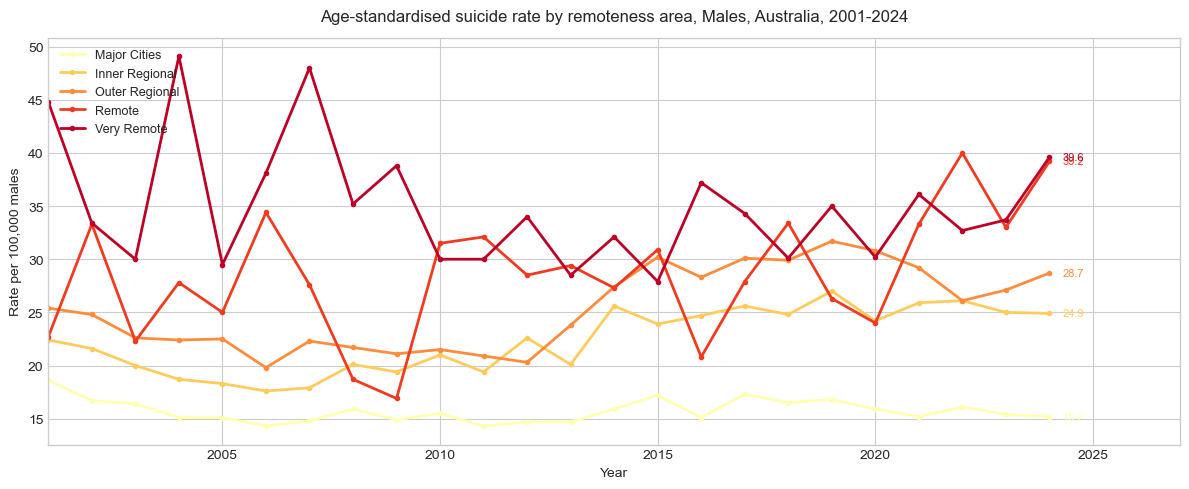

Chart saved.


In [11]:
df5_plot = df5_long[
    (df5_long['Sex'] == 'Males') &
    (df5_long['Remoteness area'].isin(REMOTE_ORDER))
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for i, area in enumerate(REMOTE_ORDER):
    subset = df5_plot[df5_plot['Remoteness area'] == area].sort_values('Year')
    ax.plot(
        subset['Year'],
        subset['Rate'],
        label=area,
        color=REMOTE_COLOURS[i],
        linewidth=2,
        marker='o',
        markersize=3
    )

# Add a note about 2024 values at the right edge
for i, area in enumerate(REMOTE_ORDER):
    latest = df5_plot[(df5_plot['Remoteness area']==area) & (df5_plot['Year']==2024)]
    if not latest.empty:
        val = latest['Rate'].values[0]
        if not np.isnan(val):
            ax.annotate(
                f"{val:.1f}",
                xy=(2024, val),
                xytext=(2024.3, val),
                fontsize=8,
                color=REMOTE_COLOURS[i],
                va='center'
            )

ax.set_title('Age-standardised suicide rate by remoteness area, Males, Australia, 2001-2024', fontsize=12, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Rate per 100,000 males')
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(2001, 2027)   # extend right to make room for annotations
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('charts/chart2_remoteness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### Interpretation -- Chart 2
In 2024, Very Remote (39.6) and Remote (39.2) have approximately 2.6x the Major Cities rate (15.2), a ratio that has persisted across the entire 2001 - 2024 period. The suicide rate in the Very Remote and Remote communities peaked in 2004 at 49.1  and in 2024 at 39.2 per 100 000, however it does fluctuate more (in 2023 the suicide rates both communities were 33.7 and 33 per 100 000 respectively) than the suicide rate for those in the Major Cities (which for the most part remains stable ar around 15 - 17 per 100 000. This could be attributed to an extremely small subset of the population (Very Remote and Remote communities), which would cause vastly different rates year to year. The suicide rates for both Very Remote and Remote communities has been on a slight positive trajectory since 2010 from ~30 to ~39.5 in 2024. This is not solely due to geography but also reduced access to mental health services compared to major cities, higher social isolation, financial stress induced (especially from farming) and a higher chance of access to lethal means such as firearms. This combined with very remote and remote communities facing arguably more stigma results in 2.6x (in 2024) the suicide rate for very remote and remote communities. From this chart, these results would suggest more specialised mental health services and preventive policies to address these issues for those living in these communities. 


## 5. Chart 3 -- Youth rates by age band, 2001-2024

We use the three most meaningful age bands for youth analysis:
15-17 (adolescents), 18-24 (young adults), and 5-17 (the broader
school-age band that AIHW uses for reporting to government).
The 0-14 band is excluded here because rates are very small and
individual values are often suppressed, making trend lines unreliable.

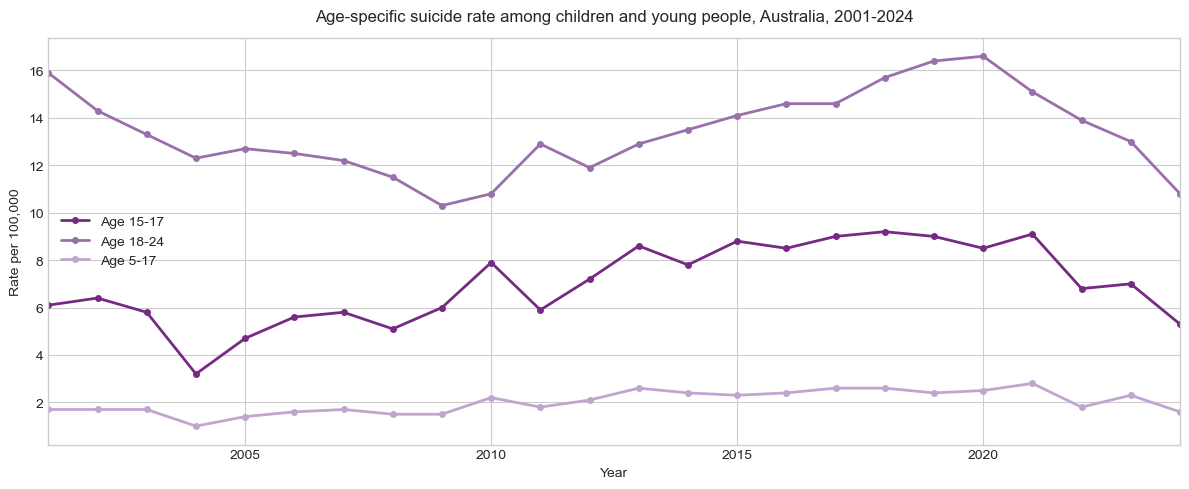

Chart saved.


In [13]:
youth_bands = ['15-17', '18-24', '5-17']
youth_colours = ['#762a83', '#9970ab', '#c2a5cf']

df13_plot = df13_long[df13_long['Age group'].isin(youth_bands)].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for i, band in enumerate(youth_bands):
    subset = df13_plot[df13_plot['Age group'] == band].sort_values('Year')
    ax.plot(
        subset['Year'],
        subset['Rate'],
        label=f'Age {band}',
        color=youth_colours[i],
        linewidth=2,
        marker='o',
        markersize=4
    )

ax.set_title('Age-specific suicide rate among children and young people, Australia, 2001-2024', fontsize=12, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Rate per 100,000')
ax.legend()
ax.set_xlim(2001, 2024)
ax.yaxis.set_major_locator(mticker.MultipleLocator(2))

plt.tight_layout()
plt.savefig('charts/chart3_youth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### Interpretation -- Chart 3

From this chart, it can be seen that for every year (2001 - 2024), the 18 - 24 age group have a higher suicide rates than the 15 - 17 age group, who in turn have higher rates than the 5 - 17 age group. The 18 - 24 age group suicide rate peaked at 18.6 in 2020. Both the 5 - 17 and 15 - 17 age groups saw a similar trend, with suicide rates rising from around 2004 (1 and 3.2 respectively) to peaking in 2021 (2.8 and 9.1). This could be attributed to these age groups suffering from anxiety, depression and suicidal tendencies induced from lockdowns during COVID, however the data does not allow for causal inference and correlation in timing does not equal casuation. This cannot be the sole determinant of rising suicide rates in this age group, as this had been the case from 2004 (12.3) to 2020 (16.6). Other factors that could have contributed to this and predate COVID are the rise of social media, smartphone use and online presense, which have coincided with increased rates of cyberbullying, depression, anxiety and suicidal tendencies and are supported by international literature. A small disclaimer that the 2023 and 2024 data are preliminary, meaning that coronial lag means that recent years may be undercounts. 



## 6. Chart 4 -- Deaths of despair by cause, Males, 1997-2024

The 'deaths of despair' framework groups suicide, alcohol-related mortality,
and drug-related mortality as causes of death linked to social and economic
distress rather than purely biological pathology. We show Males here because
the combined burden is highest in that group.

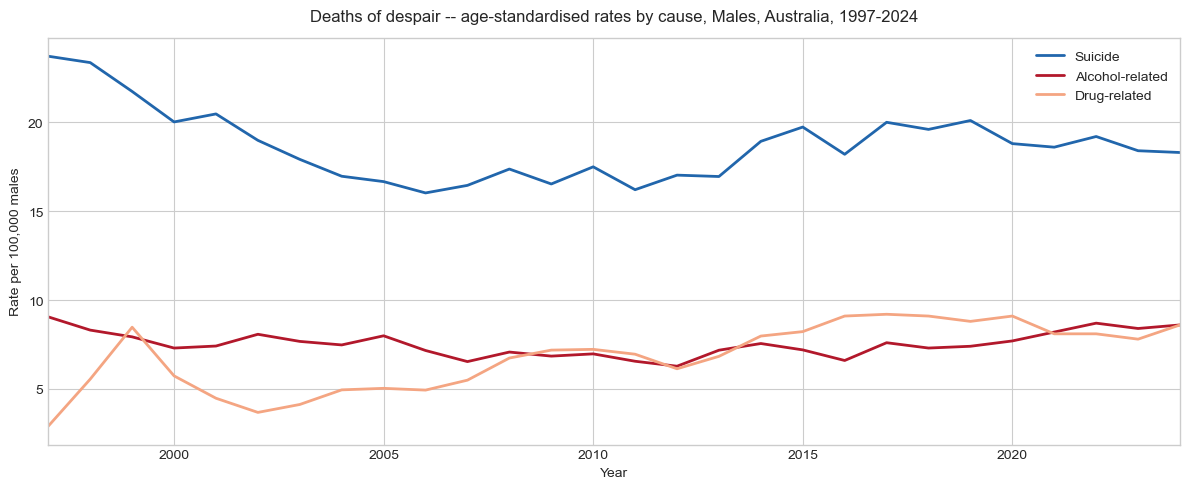

Chart saved.


In [12]:
# Show individual causes (not All combined) for Males only
causes_to_show = ['Suicide', 'Alcohol-related', 'Drug-related']
cause_colours = {'Suicide': '#2166ac', 'Alcohol-related': '#b2182b', 'Drug-related': '#f4a582'}

df16_plot = df16_long[
    (df16_long['Sex'] == 'Males') &
    (df16_long['Cause'].isin(causes_to_show))
].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for cause in causes_to_show:
    subset = df16_plot[df16_plot['Cause'] == cause].sort_values('Year')
    ax.plot(
        subset['Year'],
        subset['Rate'],
        label=cause,
        color=cause_colours[cause],
        linewidth=2
    )

ax.set_title('Deaths of despair -- age-standardised rates by cause, Males, Australia, 1997-2024', fontsize=12, pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Rate per 100,000 males')
ax.legend()
ax.set_xlim(1997, 2024)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('charts/chart4_deaths_of_despair.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### Interpretation -- Chart 4

Write your interpretation here after running the chart.
The key observation is that suicide consistently accounts for the largest share
of the three causes across the whole period. Drug-related deaths have risen
substantially since the late 1990s and are now approaching or matching
alcohol-related rates. This convergence is worth noting -- it reflects the
opioid and stimulant-related mortality trends that Australian health agencies
have been tracking closely. Together, the three causes represent a mortality
pattern linked to social conditions, not just individual health behaviours.

From this chart, death from suicides consistently is higher than deaths from alcohol-related or drug-related deaths, from a peak of 23.7 in 1997 to 18.3 in 2024 (this rate has been around 18 - 20 from 2014 to 2024). Deaths from alcohol-related instances peaked at 9.1 in 1997, decreasing to 6.3 in 2012 and then rising to 8.6 in 2024. On the other hand, deaths from drug-related instances peaked at 9.2 in 2017 and hovering around that mark to 2024, when it was recorded as 8.6. Until around the mid-late 2000s, for the most part (except for 1999), deaths from alcohol-related instances were higher than deaths from drug-related instances. One possible factor of this is alcohol consumption amongst men, which is among the highest in the world longstanding. Since then, rates of death from alcohol and drug-related instances remain similar. This can be attributed to the rise of opioid related deaths too, particularly from overdoses (which comprise of approximately 97 - 99% of drug-related deaths and most of these are unintentional). Socioeconomically disadvantaged areas report higher amounts of deaths from accidental, fatal overdoses. Furthermore, most of these overdoses involved multiple substances such as powerful synthetic opioids such as fentanyl and nitazenes. One small disclaimer to note is that the AIHW classifies drug-related deaths as accidental poisoning, which is unintentional. This is different to suicide, which is intnetional and the deaths from despair combines both these measures into one. 

## 7. Chart 5 -- Top psychosocial risk factors by sex, 2024

NMD17 records the most frequently documented psychosocial risk factors
present at time of death, coded using ICD-10 Z-codes. We compare the
top 5 factors for Males and Females across two age groups (0-24 and 25-34)
in the most recent year (2024).

These are documented risk factors -- they do not imply causation and
reflect what was recorded by the coroner at time of death, not a
complete clinical assessment.

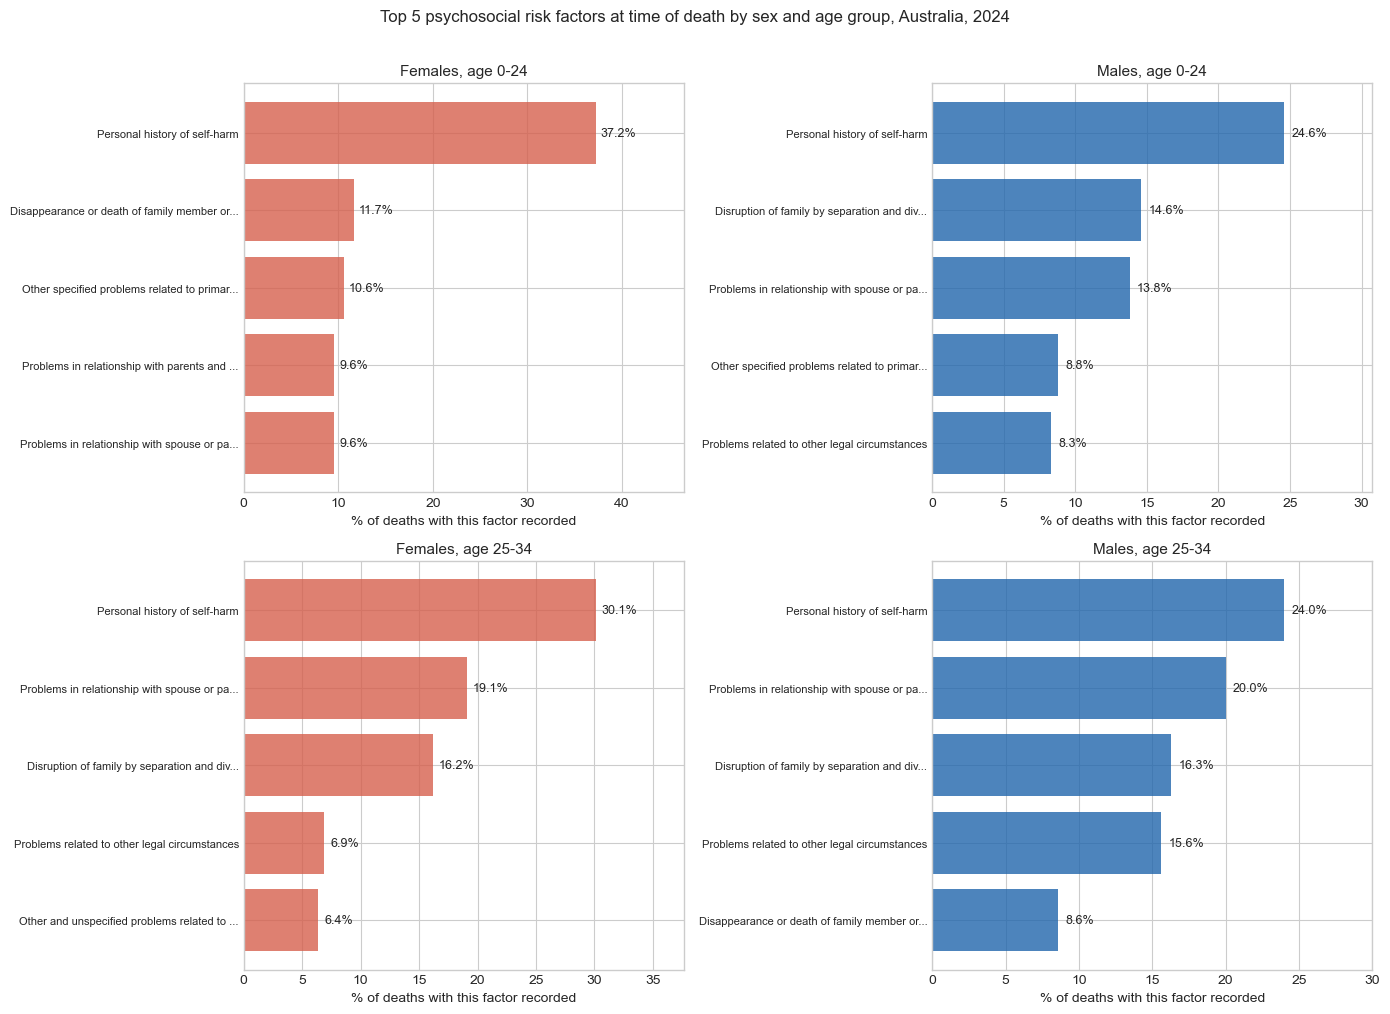

Chart saved.


In [16]:
# Build a 2x2 subplot: rows = age group (0-24, 25-34), cols = sex
recent_yr = df17['Year'].max()
age_groups_to_show = ['0-24', '25-34']
sexes = ['Females', 'Males']
bar_colours = {'Females': '#d6604d', 'Males': '#2166ac'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Top 5 psychosocial risk factors at time of death by sex and age group, Australia, {recent_yr}', fontsize=12, y=1.01)

for row_i, age_grp in enumerate(age_groups_to_show):
    for col_i, sex in enumerate(sexes):
        ax = axes[row_i][col_i]

        subset = df17[
            (df17['Year'] == recent_yr) &
            (df17['Sex'] == sex) &
            (df17['Age_group'] == age_grp)
        ].nsmallest(5, 'Rank').sort_values('Pct_with_factor')

        if subset.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{sex}, age {age_grp}')
            continue

        # Shorten long labels to fit horizontal axis
        # We take the last 5 words max to keep bars readable
        labels = [
            label if len(label) <= 45 else label[:42] + '...'
            for label in subset['Risk_factor_label']
        ]

        bars = ax.barh(
            labels,
            subset['Pct_with_factor'],
            color=bar_colours[sex],
            alpha=0.8
        )

        # Add percentage labels on bars
        for bar, val in zip(bars, subset['Pct_with_factor']):
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%',
                va='center',
                fontsize=9
            )

        ax.set_title(f'{sex}, age {age_grp}', fontsize=11)
        ax.set_xlabel('% of deaths with this factor recorded')
        ax.set_xlim(0, subset['Pct_with_factor'].max() * 1.25)
        ax.tick_params(axis='y', labelsize=8)

# Convert Rank and numeric columns -- object dtype causes nsmallest() to fail
df17['Rank'] = pd.to_numeric(df17['Rank'], errors='coerce')
df17['Pct_with_factor'] = pd.to_numeric(df17['Pct_with_factor'], errors='coerce')
df17['Deaths_with_factor'] = pd.to_numeric(df17['Deaths_with_factor'], errors='coerce')

plt.tight_layout()
plt.savefig('charts/chart5_risk_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

### Interpretation -- Chart 5

In all sexes and age groups, the top psychosocial risk factors at time of death is personal history of self-harm, which is clinically significant. This suggests prior self-harm is the strongest documented predictor in
this dataset, consistent with international clinical literature
on suicide risk stratification. Beyond this, the differences between age groups are also meaningful: for Males 25-34,
relationship breakdown (Z630, Z635) and legal problems (Z653) appear
prominently alongside Z915, which reflects patterns seen in community
mental health presentations in that demographic. For 25-34 year old women, 6.9% psychosocial risk factors could be related to legal circumstances compared to 15.6% for men aged between 25 - 34. This could be attributed to the lack of services available to aid those men suffering from precarious financial situations brought upon by relationship breakdowns, custody disputes or by legal difficulties. Another possible point for further investigation is 14.6% of men below 25 having disruption of family and 11.7% of women below 25 having disappearance or death of a family member as their top psychosocial risk factor at death. These are not just
statistics, each Z-code represents a real, documentable life circumstance
that mental health services can potentially address upstream. 


## 8. Summary of findings

Using AIHW National Mortality Database (NMD) data in April 2026, covering ICD-10 codes X60-X84, Chart 1 shows female suicide rate peaking in 1971 at 10.4 and then plateauing to around 5-6 per 100 000 since 1980 whereas the male suicide rate peaked in the 1990s (1997 at 23.7), plateauing at around 18 - 20 from 2014 onwards. During this time, the male: female suicide ratio has remained constant at around 3:1. The Very Remote and Remote communities have consistently recorded a higher suicide rate than those in Major Cities (in 2024, it was 39.6 and 39.2 vs 15.2 in Major Cities at a ratio of ~2.6x). There has been a rise in youth suicides since 2004 for 15 - 17 and 5 - 17 age groups and from 2009 for 18 - 24 age group to a peak around 2020/2021. One limitation of this is that we do not have the ability to contextualise current youth rates against the broader historial trend seen in NMD1 for the national series (the rate dropped during the 2000s for all age groups but we cannot deduce whether 2001 was the peak or prior to 2001. A disclaimer too is that 2023 and 2024 are preliminary date (ie coronial lag would indicate that those years are undercounts). The rate of suicides is higher than rates from alcohol and drug-related despair for men, although upto around the mid-late 2000s, the rate of deaths from alcohol related offences was higher than that from drug related offences (rise of deaths from opioid overdoses coincide from this time onwards). All sexes and all age groups have the highest psychosocial risk factor of death from a personal history of self-harm, which is clinically significant and consistent with clincial literature research on this topic. 

## 9. Technical notes

**Data source:** AIHW National Mortality Database, Suicide and Self-harm Monitoring,
published April 2026. ICD-10 codes X60-X84, Y87.0.

**Age-standardised rates** (NMD1, NMD5, NMD16) use the 2001 Australian standard
population, enabling valid comparisons across time and geography by controlling
for differences in population age structure.

**Age-specific rates** (NMD13) are used for youth age bands where
age-standardisation is not applied to individual narrow age groups.

**Suppressed values:** Cells marked 'n.p.' by AIHW indicate counts too small
to publish (typically fewer than 5 deaths). These are treated as NaN in this
analysis and excluded from chart lines. They represent real events, not zero.

**Provisional data:** Deaths registered in 2023 and 2024 are based on
preliminary data subject to revision as coronial findings are finalised.
Rates in the most recent two years may undercount actual suicide deaths.

**Psychosocial risk factors (NMD17):** Coded using ICD-10 Chapter 21 Z-codes
by the coroner at time of death. Presence of a factor does not imply causation
and reflects documented circumstances rather than a comprehensive clinical assessment.